<a href="https://colab.research.google.com/github/sfaril12/dataset_diabetes_perrcobaan/blob/main/klasifikasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasifikasi Diabetes Readmission Menggunakan Random Forest
## Dengan dan Tanpa PCA (Principal Component Analysis)

**Dataset:** Diabetic Data (130-US Hospitals, 1999-2008)  
**Pipeline:** Data Cleaning -> PCA -> Train/Test Split -> Random Forest -> Evaluasi

## Tahap 1: Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
print('Library berhasil dimuat!')

Library berhasil dimuat!


## Tahap 2: Memuat Data

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/sfaril12/dataset_diabetes_perrcobaan/refs/heads/main/diabetic_data.csv')
print(f'Ukuran dataset awal: {df.shape[0]} baris x {df.shape[1]} kolom')
df.head()

Ukuran dataset awal: 101766 baris x 50 kolom


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


## Tahap 3: Pembersihan Data
### 3a. Menangani Nilai yang Hilang

In [3]:
# Ganti '?' dengan NaN
df.replace('?', np.nan, inplace=True)

# Tampilkan kolom dengan missing values
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_info = missing_pct[missing_pct > 0].sort_values(ascending=False)
print('Kolom dengan missing values:')
for col, pct in missing_info.items():
    print(f'  {col:25s}: {pct:.2f}%')

# Isi missing values pada kolom diagnosis yang akan dipakai
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col].fillna(df[col].mode()[0], inplace=True)
    print(f"  -> '{col}' diisi dengan modus: '{df[col].mode()[0]}'")

print(f'\nMissing values pada kolom yang dipakai: 0')

Kolom dengan missing values:
  weight                   : 96.86%
  max_glu_serum            : 94.75%
  A1Cresult                : 83.28%
  medical_specialty        : 49.08%
  payer_code               : 39.56%
  race                     : 2.23%
  diag_3                   : 1.40%
  diag_2                   : 0.35%
  diag_1                   : 0.02%
  -> 'diag_1' diisi dengan modus: '428'
  -> 'diag_2' diisi dengan modus: '276'
  -> 'diag_3' diisi dengan modus: '250'

Missing values pada kolom yang dipakai: 0


### 3b. Menghapus Data Duplikasi

In [4]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)
print(f'Sebelum: {before} | Sesudah: {after} | Dihapus: {before - after}')

Sebelum: 101766 | Sesudah: 101766 | Dihapus: 0


### 3c. Feature Engineering: Grouping Kode Diagnosis ICD-9

Kode diagnosis ICD-9 memiliki 700+ nilai unik. Untuk mengurangi kardinalitas,
kita kelompokkan ke kategori penyakit utama.

In [5]:
def map_diagnosis_category(diag):
    """Mengelompokkan kode ICD-9 ke kategori penyakit utama."""
    if pd.isna(diag):
        return 'Other'
    diag = str(diag).strip()
    if diag.startswith('V') or diag.startswith('E'):
        return 'External'
    try:
        code = float(diag)
    except ValueError:
        return 'Other'

    if 1 <= code <= 139:      return 'Infectious'
    elif 140 <= code <= 239:   return 'Neoplasms'
    elif 240 <= code <= 279:   return 'Endocrine'      # Diabetes = 250.xx
    elif 280 <= code <= 289:   return 'Blood'
    elif 290 <= code <= 319:   return 'Mental'
    elif 320 <= code <= 389:   return 'Nervous'
    elif 390 <= code <= 459:   return 'Circulatory'
    elif 460 <= code <= 519:   return 'Respiratory'
    elif 520 <= code <= 579:   return 'Digestive'
    elif 580 <= code <= 629:   return 'Genitourinary'
    elif 630 <= code <= 679:   return 'Pregnancy'
    elif 680 <= code <= 709:   return 'Skin'
    elif 710 <= code <= 739:   return 'Musculoskeletal'
    elif 740 <= code <= 759:   return 'Congenital'
    elif 760 <= code <= 779:   return 'Perinatal'
    elif 780 <= code <= 799:   return 'Symptoms'
    elif 800 <= code <= 999:   return 'Injury'
    else:                      return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col + '_cat'] = df[col].apply(map_diagnosis_category)
    n_cat = df[col + '_cat'].nunique()
    print(f'  {col} -> {col}_cat ({n_cat} kategori)')

print('\nDistribusi diagnosis utama (diag_1_cat):')
print(df['diag_1_cat'].value_counts())

  diag_1 -> diag_1_cat (17 kategori)
  diag_2 -> diag_2_cat (17 kategori)
  diag_3 -> diag_3_cat (17 kategori)

Distribusi diagnosis utama (diag_1_cat):
diag_1_cat
Circulatory        30357
Endocrine          11459
Respiratory        10407
Digestive           9208
Symptoms            7636
Injury              6974
Genitourinary       5078
Musculoskeletal     4957
Neoplasms           3433
Infectious          2768
Skin                2530
Mental              2262
External            1645
Nervous             1211
Blood               1103
Pregnancy            687
Congenital            51
Name: count, dtype: int64


### 3d. Feature Engineering: Fitur Agregat dari Kolom Obat

Dari 23 kolom obat diabetes, kita buat fitur ringkasan:
- `num_med_prescribed`: berapa obat yang diresepkan
- `num_med_changed`: berapa obat yang dosisnya diubah (Up/Down)

In [6]:
all_med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                'miglitol', 'troglitazone', 'tolazamide', 'insulin',
                'glyburide-metformin', 'glipizide-metformin',
                'glimepiride-pioglitazone', 'metformin-rosiglitazone',
                'metformin-pioglitazone']

# Hitung jumlah obat yang diresepkan (bukan 'No')
df['num_med_prescribed'] = sum((df[c] != 'No').astype(int) for c in all_med_cols)

# Hitung jumlah obat yang dosisnya diubah (Up atau Down)
df['num_med_changed'] = sum(df[c].isin(['Up', 'Down']).astype(int) for c in all_med_cols)

print(f'num_med_prescribed: rata-rata {df["num_med_prescribed"].mean():.1f} obat')
print(f'num_med_changed   : rata-rata {df["num_med_changed"].mean():.1f} obat')

num_med_prescribed: rata-rata 1.2 obat
num_med_changed   : rata-rata 0.3 obat


### 3e. Feature Engineering: Rasio per Hari Rawat

Membuat fitur baru yang merepresentasikan intensitas perawatan per hari.

In [7]:
df['lab_per_day'] = df['num_lab_procedures'] / (df['time_in_hospital'] + 1)
df['med_per_day'] = df['num_medications'] / (df['time_in_hospital'] + 1)
df['proc_per_day'] = df['num_procedures'] / (df['time_in_hospital'] + 1)
df['total_visits'] = df['number_outpatient'] + df['number_emergency'] + df['number_inpatient']

print('Fitur baru berhasil dibuat:')
print('  lab_per_day  : prosedur lab per hari rawat')
print('  med_per_day  : obat per hari rawat')
print('  proc_per_day : prosedur per hari rawat')
print('  total_visits : total kunjungan sebelumnya')

Fitur baru berhasil dibuat:
  lab_per_day  : prosedur lab per hari rawat
  med_per_day  : obat per hari rawat
  proc_per_day : prosedur per hari rawat
  total_visits : total kunjungan sebelumnya


### 3f. Konversi Target ke Binary

Target asli memiliki 3 kelas: `NO`, `<30`, `>30`.  
Dikonversi ke binary: **Readmitted (1)** vs **Tidak Readmitted (0)**.

In [8]:
print('Distribusi target asli:')
print(df['readmitted'].value_counts())

df['target'] = (df['readmitted'] != 'NO').astype(int)

print(f'\nDistribusi target binary:')
print(f'  0 (Tidak Readmitted): {(df["target"] == 0).sum()}')
print(f'  1 (Readmitted)      : {(df["target"] == 1).sum()}')

Distribusi target asli:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Distribusi target binary:
  0 (Tidak Readmitted): 54864
  1 (Readmitted)      : 46902


### 3f-alt. Persiapan Target 3 Kelas

Untuk perbandingan, kita juga akan menyiapkan target dengan kelas asli: `NO`, `<30`, dan `>30`.

In [9]:
df['target_3class'] = LabelEncoder().fit_transform(df['readmitted'])
print('Distribusi target 3 kelas:')
print(df['readmitted'].value_counts())
print('\nMapping Label (LabelEncoder):')
for i, class_name in enumerate(['<30', '>30', 'NO']):
    print(f'  {i}: {class_name}')

Distribusi target 3 kelas:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Mapping Label (LabelEncoder):
  0: <30
  1: >30
  2: NO


### 3g. Seleksi Fitur

Berdasarkan analisis, dipilih fitur-fitur yang relevan secara klinis:
- **Dihapus:** ID (encounter_id, patient_nbr), demografis bias (race, gender),
  kolom >40% missing (weight, max_glu_serum, A1Cresult, medical_specialty, payer_code),
  obat jarang dipakai (examide, citoglipton, dll)
- **Dipertahankan:** Fitur klinis, diagnosis, obat penting, fitur rekayasa

In [10]:
selected_features = [
    # Demografis (1)
    'age',

    # Informasi Rawat Inap (4)
    'admission_type_id',
    'discharge_disposition_id',
    'admission_source_id',
    'time_in_hospital',

    # Prosedur & Pengobatan (6)
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',

    # Diagnosis (4)
    'diag_1_cat',
    'diag_2_cat',
    'diag_3_cat',
    'number_diagnoses',

    # Obat individual penting (2)
    'insulin',
    'metformin',

    # Ringkasan pengobatan (2)
    'change',
    'diabetesMed',

    # Fitur rekayasa (6)
    'num_med_prescribed',
    'num_med_changed',
    'lab_per_day',
    'med_per_day',
    'proc_per_day',
    'total_visits',
]

print(f'Fitur yang dipilih ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

# Buat dataframe baru
df_selected = df[selected_features + ['target']].copy()

Fitur yang dipilih (25):
   1. age
   2. admission_type_id
   3. discharge_disposition_id
   4. admission_source_id
   5. time_in_hospital
   6. num_lab_procedures
   7. num_procedures
   8. num_medications
   9. number_outpatient
  10. number_emergency
  11. number_inpatient
  12. diag_1_cat
  13. diag_2_cat
  14. diag_3_cat
  15. number_diagnoses
  16. insulin
  17. metformin
  18. change
  19. diabetesMed
  20. num_med_prescribed
  21. num_med_changed
  22. lab_per_day
  23. med_per_day
  24. proc_per_day
  25. total_visits


### 3h. Label Encoding untuk Fitur Kategorikal

In [11]:
cat_cols = df_selected.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_selected[col] = le.fit_transform(df_selected[col].astype(str))
    label_encoders[col] = le
    print(f"  '{col}': {len(le.classes_)} kelas -> {list(le.classes_[:5])}{'...' if len(le.classes_) > 5 else ''}")

print(f'\nDataset final: {df_selected.shape[0]} baris x {df_selected.shape[1]} kolom')
print(f'Semua numerik: {df_selected.select_dtypes(include="object").shape[1] == 0}')
df_selected.head()

  'age': 10 kelas -> ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)']...
  'diag_1_cat': 17 kelas -> ['Blood', 'Circulatory', 'Congenital', 'Digestive', 'Endocrine']...
  'diag_2_cat': 17 kelas -> ['Blood', 'Circulatory', 'Congenital', 'Digestive', 'Endocrine']...
  'diag_3_cat': 17 kelas -> ['Blood', 'Circulatory', 'Congenital', 'Digestive', 'Endocrine']...
  'insulin': 4 kelas -> ['Down', 'No', 'Steady', 'Up']
  'metformin': 4 kelas -> ['Down', 'No', 'Steady', 'Up']
  'change': 2 kelas -> ['Ch', 'No']
  'diabetesMed': 2 kelas -> ['No', 'Yes']

Dataset final: 101766 baris x 26 kolom
Semua numerik: True


,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1_cat,diag_2_cat,diag_3_cat,number_diagnoses,insulin,metformin,change,diabetesMed,num_med_prescribed,num_med_changed,lab_per_day,med_per_day,proc_per_day,total_visits,target
0,0,6,25,1,1,41,0,1,0,0,0,4,4,4,1,1,1,1,0,0,0,20.500000,0.500000,0.000000,0,0
1,1,1,1,7,3,59,0,18,0,0,0,4,4,4,9,3,1,0,1,1,1,14.750000,4.500000,0.000000,0,1
2,2,1,1,7,2,11,5,13,2,0,1,13,4,5,6,1,1,1,1,1,0,3.666667,4.333333,1.666667,3,0
3,3,1,1,7,2,44,1,16,0,0,0,7,4,1,7,3,1,0,1,1,1,14.666667,5.333333,0.333333,0,0
4,4,1,1,7,1,51,0,8,0,0,0,11,11,4,5,2,1,0,1,2,0,25.500000,4.000000,0.000000,0,0


## Tahap 4: Pemisahan Fitur dan Target

In [12]:
X = df_selected.drop(columns=['target'])
y = df_selected['target']

print(f'Fitur (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'  0 (Tidak Readmitted): {(y == 0).sum()} ({(y == 0).mean()*100:.1f}%)')
print(f'  1 (Readmitted)      : {(y == 1).sum()} ({(y == 1).mean()*100:.1f}%)')

Fitur (X): (101766, 25)
Target (y): (101766,)
  0 (Tidak Readmitted): 54864 (53.9%)
  1 (Readmitted)      : 46902 (46.1%)


## Tahap 5: Standardisasi Data

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Data distandarisasi (mean~0, std~1)')
print(f'Mean fitur pertama: {X_scaled[:, 0].mean():.6f}')
print(f'Std fitur pertama : {X_scaled[:, 0].std():.6f}')

Data distandarisasi (mean~0, std~1)
Mean fitur pertama: 0.000000
Std fitur pertama : 1.000000


## Tahap 6: PCA (Principal Component Analysis)

Menentukan jumlah komponen optimal berdasarkan varians kumulatif yang dijelaskan.

In [14]:
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_85 = np.argmax(cumulative_variance >= 0.85) + 1
n_80 = np.argmax(cumulative_variance >= 0.80) + 1

print(f'Jumlah fitur asli: {X.shape[1]}')
print(f'\nVarians kumulatif:')
print(f'  80% varians -> {n_80} komponen')
print(f'  85% varians -> {n_85} komponen')
print(f'  90% varians -> {n_90} komponen')
print(f'  95% varians -> {n_95} komponen')

n_optimal = n_95
print(f'\n>> Komponen optimal: {n_optimal} (95% varians)')

Jumlah fitur asli: 25

Varians kumulatif:
  80% varians -> 14 komponen
  85% varians -> 15 komponen
  90% varians -> 17 komponen
  95% varians -> 19 komponen

>> Komponen optimal: 19 (95% varians)


### Visualisasi Varians PCA

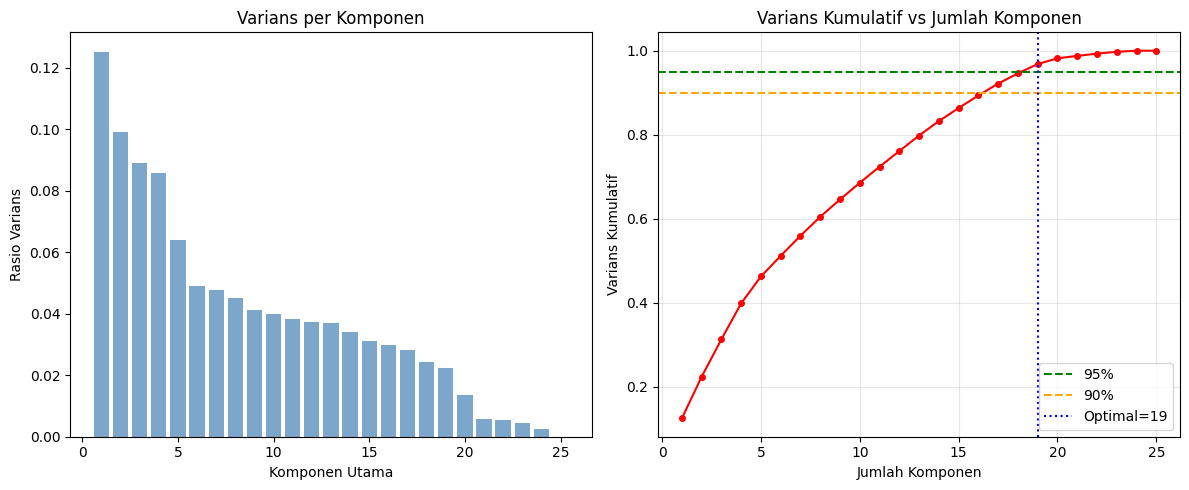

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
        pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
plt.xlabel('Komponen Utama')
plt.ylabel('Rasio Varians')
plt.title('Varians per Komponen')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
         'ro-', markersize=4)
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.90, color='orange', linestyle='--', label='90%')
plt.axvline(x=n_optimal, color='b', linestyle=':', label=f'Optimal={n_optimal}')
plt.xlabel('Jumlah Komponen')
plt.ylabel('Varians Kumulatif')
plt.title('Varians Kumulatif vs Jumlah Komponen')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

### Terapkan PCA

In [16]:
pca = PCA(n_components=n_optimal)
X_pca = pca.fit_transform(X_scaled)
print(f'Data setelah PCA: {X_pca.shape}')
print(f'Varians dipertahankan: {pca.explained_variance_ratio_.sum() * 100:.2f}%')

Data setelah PCA: (101766, 19)
Varians dipertahankan: 96.83%


## Tahap 7: Pembagian Data (80/20)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y)

print(f'[Tanpa PCA] Train: {X_train.shape} | Test: {X_test.shape}')
print(f'[Dengan PCA] Train: {X_train_pca.shape} | Test: {X_test_pca.shape}')

[Tanpa PCA] Train: (81412, 25) | Test: (20354, 25)
[Dengan PCA] Train: (81412, 19) | Test: (20354, 19)


## Tahap 8: Model Random Forest - Tanpa PCA

Membangun model klasifikasi menggunakan semua fitur asli (tanpa reduksi dimensi).

In [18]:
rf_no_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print('Melatih model Random Forest (Tanpa PCA)...')
rf_no_pca.fit(X_train, y_train)
y_pred = rf_no_pca.predict(X_test)
print('Selesai!')

Melatih model Random Forest (Tanpa PCA)...
Selesai!


### Evaluasi Model Tanpa PCA

In [19]:
acc1 = accuracy_score(y_test, y_pred)
prec1 = precision_score(y_test, y_pred, average='weighted')
rec1 = recall_score(y_test, y_pred, average='weighted')
f1_1 = f1_score(y_test, y_pred, average='weighted')

print('=' * 55)
print(f'  EVALUASI MODEL TANPA PCA ({X.shape[1]} fitur)')
print('=' * 55)
print(f'  Akurasi  : {acc1:.4f} ({acc1*100:.2f}%)')
print(f'  Presisi  : {prec1:.4f} ({prec1*100:.2f}%)')
print(f'  Recall   : {rec1:.4f} ({rec1*100:.2f}%)')
print(f'  F1-Score : {f1_1:.4f} ({f1_1*100:.2f}%)')
print('=' * 55)

target_names = ['Tidak Readmitted', 'Readmitted']
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=target_names))

  EVALUASI MODEL TANPA PCA (25 fitur)
  Akurasi  : 0.6358 (63.58%)
  Presisi  : 0.6344 (63.44%)
  Recall   : 0.6358 (63.58%)
  F1-Score : 0.6339 (63.39%)

Classification Report:
                  precision    recall  f1-score   support

Tidak Readmitted       0.65      0.70      0.68     10973
      Readmitted       0.62      0.56      0.59      9381

        accuracy                           0.64     20354
       macro avg       0.63      0.63      0.63     20354
    weighted avg       0.63      0.64      0.63     20354



### Confusion Matrix - Tanpa PCA

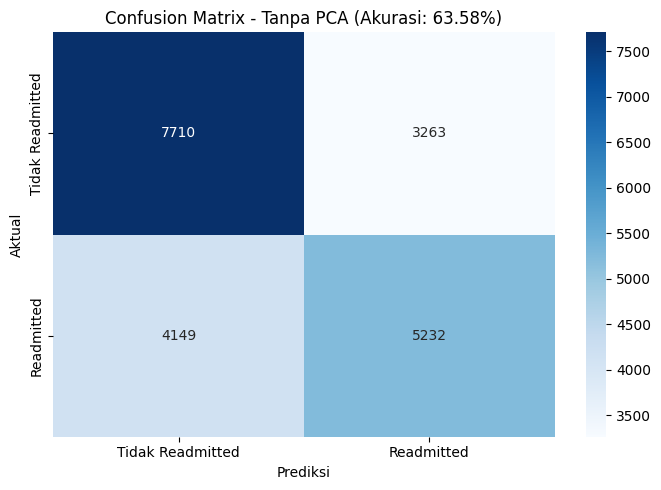

In [20]:
cm1 = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - Tanpa PCA (Akurasi: {acc1*100:.2f}%)')
plt.tight_layout()
plt.savefig('confusion_matrix_tanpa_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance

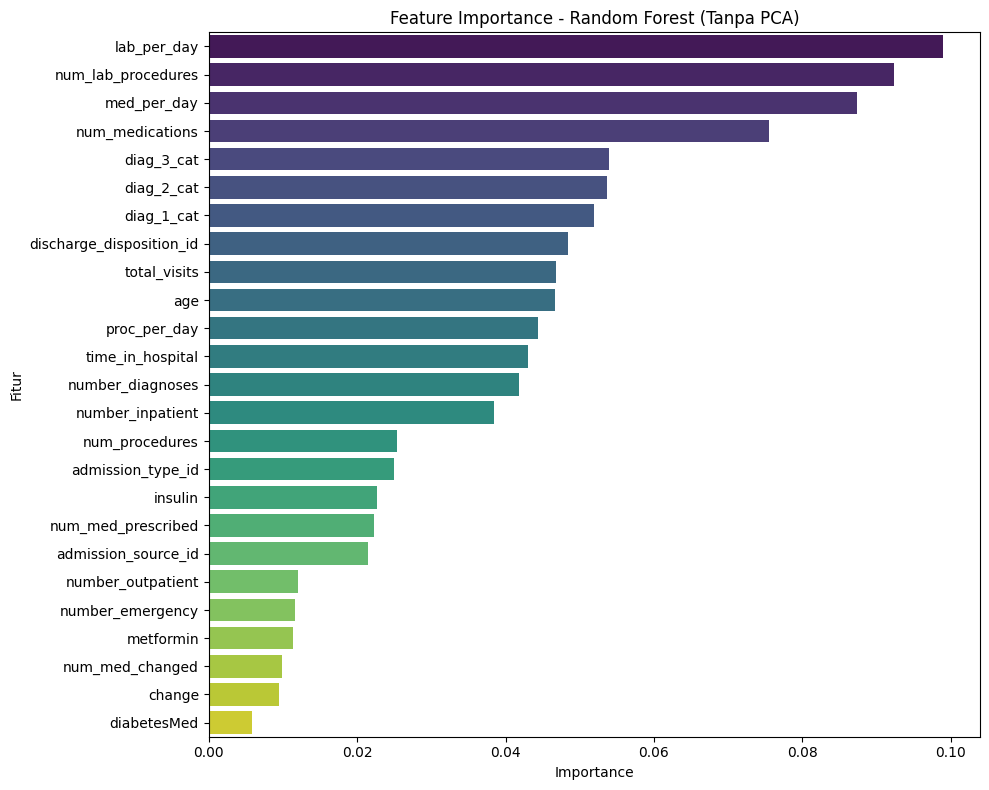

Top 10 Fitur Terpenting:
  lab_per_day                   : 0.0990
  num_lab_procedures            : 0.0923
  med_per_day                   : 0.0874
  num_medications               : 0.0755
  diag_3_cat                    : 0.0539
  diag_2_cat                    : 0.0537
  diag_1_cat                    : 0.0519
  discharge_disposition_id      : 0.0484
  total_visits                  : 0.0468
  age                           : 0.0466


In [21]:
feat_imp = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': rf_no_pca.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='Importance', y='Fitur', palette='viridis')
plt.title('Feature Importance - Random Forest (Tanpa PCA)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Fitur Terpenting:')
for _, row in feat_imp.head(10).iterrows():
    print(f'  {row["Fitur"]:30s}: {row["Importance"]:.4f}')

## Tahap 9: Model Random Forest - Dengan PCA

Membangun model menggunakan data yang telah direduksi dimensinya dengan PCA.

In [22]:
rf_pca = RandomForestClassifier(
    n_estimators=500,
    max_depth=35,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print(f'Melatih model Random Forest (Dengan PCA, {n_optimal} komponen)...')
rf_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = rf_pca.predict(X_test_pca)
print('Selesai!')

Melatih model Random Forest (Dengan PCA, 19 komponen)...
Selesai!


### Evaluasi Model Dengan PCA

In [23]:
acc2 = accuracy_score(y_test_pca, y_pred_pca)
prec2 = precision_score(y_test_pca, y_pred_pca, average='weighted')
rec2 = recall_score(y_test_pca, y_pred_pca, average='weighted')
f1_2 = f1_score(y_test_pca, y_pred_pca, average='weighted')

print('=' * 55)
print(f'  EVALUASI MODEL DENGAN PCA ({n_optimal} komponen)')
print('=' * 55)
print(f'  Varians  : {pca.explained_variance_ratio_.sum() * 100:.2f}%')
print(f'  Akurasi  : {acc2:.4f} ({acc2*100:.2f}%)')
print(f'  Presisi  : {prec2:.4f} ({prec2*100:.2f}%)')
print(f'  Recall   : {rec2:.4f} ({rec2*100:.2f}%)')
print(f'  F1-Score : {f1_2:.4f} ({f1_2*100:.2f}%)')
print('=' * 55)

print('\nClassification Report:')
print(classification_report(y_test_pca, y_pred_pca, target_names=target_names))

  EVALUASI MODEL DENGAN PCA (19 komponen)
  Varians  : 96.83%
  Akurasi  : 0.6232 (62.32%)
  Presisi  : 0.6220 (62.20%)
  Recall   : 0.6232 (62.32%)
  F1-Score : 0.6164 (61.64%)

Classification Report:
                  precision    recall  f1-score   support

Tidak Readmitted       0.63      0.74      0.68     10973
      Readmitted       0.62      0.48      0.54      9381

        accuracy                           0.62     20354
       macro avg       0.62      0.61      0.61     20354
    weighted avg       0.62      0.62      0.62     20354



### Optimasi Model PCA

Mencoba beberapa konfigurasi untuk menemukan akurasi terbaik.

### Confusion Matrix - Dengan PCA

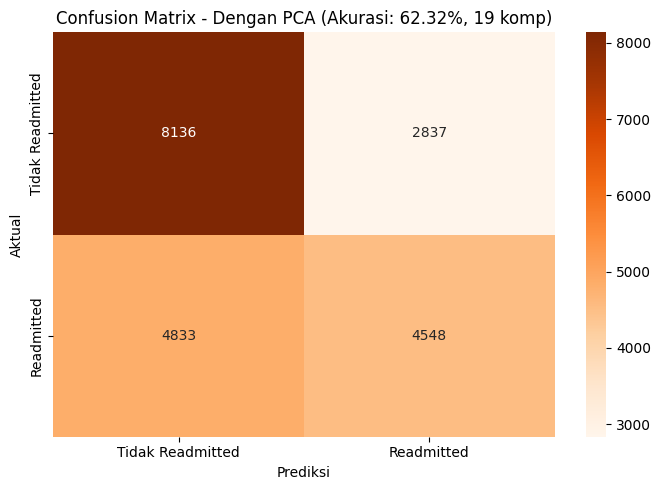

In [26]:
cm2 = confusion_matrix(y_test_pca, y_pred_pca)
plt.figure(figsize=(7, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - Dengan PCA (Akurasi: {acc2*100:.2f}%, {n_optimal} komp)')
plt.tight_layout()
plt.savefig('confusion_matrix_dengan_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## Tahap 10: Perbandingan Tanpa PCA dan Pakai PCA


In [27]:
print('=' * 65)
print(f'  {"Metrik":12s} | {"Tanpa PCA":20s} | {"Dengan PCA":20s}')
print('=' * 65)
print(f'  {"Akurasi":12s} | {acc1:.4f} ({acc1*100:.2f}%){"":5s} | {acc2:.4f} ({acc2*100:.2f}%)')
print(f'  {"Presisi":12s} | {prec1:.4f} ({prec1*100:.2f}%){"":5s} | {prec2:.4f} ({prec2*100:.2f}%)')
print(f'  {"Recall":12s} | {rec1:.4f} ({rec1*100:.2f}%){"":5s} | {rec2:.4f} ({rec2*100:.2f}%)')
print(f'  {"F1-Score":12s} | {f1_1:.4f} ({f1_1*100:.2f}%){"":5s} | {f1_2:.4f} ({f1_2*100:.2f}%)')
print('=' * 65)
print(f'\n  Fitur asli    : {X.shape[1]}')
print(f'  Komponen PCA  : {n_optimal}')
print(f'  Reduksi       : {X.shape[1]} -> {n_optimal} ({(1-n_optimal/X.shape[1])*100:.1f}%)')

  Metrik       | Tanpa PCA            | Dengan PCA          
  Akurasi      | 0.6358 (63.58%)      | 0.6232 (62.32%)
  Presisi      | 0.6344 (63.44%)      | 0.6220 (62.20%)
  Recall       | 0.6358 (63.58%)      | 0.6232 (62.32%)
  F1-Score     | 0.6339 (63.39%)      | 0.6164 (61.64%)

  Fitur asli    : 25
  Komponen PCA  : 19
  Reduksi       : 25 -> 19 (24.0%)


In [31]:
print('SELESAI!')
print(f'\nRingkasan Hasil:')
print(f'  Tanpa PCA : Akurasi {acc1*100:.2f}%, F1 {f1_1*100:.2f}%')
print(f'  Dengan PCA: Akurasi {acc2*100:.2f}%, F1 {f1_2*100:.2f}%')

SELESAI!

Ringkasan Hasil:
  Tanpa PCA : Akurasi 63.58%, F1 63.39%
  Dengan PCA: Akurasi 62.32%, F1 61.64%


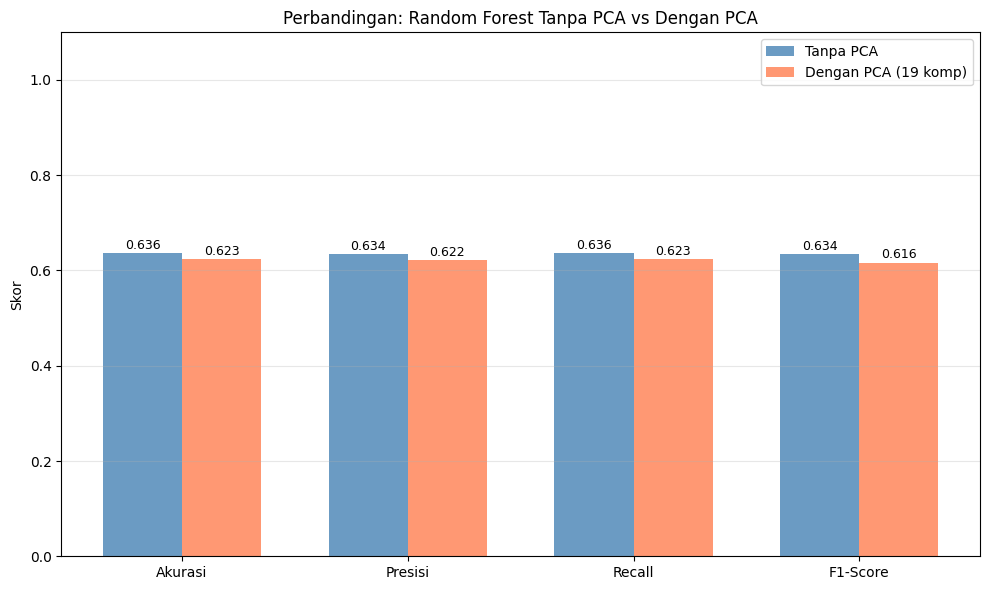

In [30]:
metrics = ['Akurasi', 'Presisi', 'Recall', 'F1-Score']
v1 = [acc1, prec1, rec1, f1_1]
v2 = [acc2, prec2, rec2, f1_2]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
w = 0.35
b1 = ax.bar(x - w/2, v1, w, label='Tanpa PCA', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, v2, w, label=f'Dengan PCA ({n_optimal} komp)', color='coral', alpha=0.8)
ax.set_ylabel('Skor')
ax.set_title('Perbandingan: Random Forest Tanpa PCA vs Dengan PCA')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
for b in b1:
    h = b.get_height()
    ax.annotate(f'{h:.3f}', xy=(b.get_x() + b.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
for b in b2:
    h = b.get_height()
    ax.annotate(f'{h:.3f}', xy=(b.get_x() + b.get_width()/2, h),
                xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

## Tahap 11: Eksperimen Versi 3 Kelas

Sekarang kita latih model menggunakan target original (3 kelas) untuk melihat perbedaan performanya.

In [28]:
y3 = df['target_3class']
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_scaled, y3, test_size=0.2, random_state=42, stratify=y3
)

rf_3class = RandomForestClassifier(
    n_estimators=300, max_depth=30, class_weight='balanced', n_jobs=-1, random_state=42
)

print('Melatih model Random Forest (3 Kelas)...')
rf_3class.fit(X_train3, y_train3)
y_pred3 = rf_3class.predict(X_test3)

acc3class = accuracy_score(y_test3, y_pred3)
print(f'Selesai! Akurasi 3 Kelas: {acc3class*100:.2f}%')
print('\nClassification Report (3 Kelas):')
print(classification_report(y_test3, y_pred3, target_names=['<30', '>30', 'NO']))

Melatih model Random Forest (3 Kelas)...
Selesai! Akurasi 3 Kelas: 57.88%

Classification Report (3 Kelas):
              precision    recall  f1-score   support

         <30       0.40      0.02      0.04      2272
         >30       0.49      0.37      0.42      7109
          NO       0.61      0.83      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.50      0.41      0.39     20354
weighted avg       0.55      0.58      0.53     20354



### Perbandingan Ringkas: 2 Kelas vs 3 Kelas

In [29]:
print('='*40)
print(f'Akurasi Versi 2 Kelas: {acc1*100:.2f}%')
print(f'Akurasi Versi 3 Kelas: {acc3class*100:.2f}%')
print('='*40)
print('Catatan: Akurasi pada 3 kelas biasanya lebih rendah karena kompleksitas prediksi yang lebih tinggi.')

Akurasi Versi 2 Kelas: 63.58%
Akurasi Versi 3 Kelas: 57.88%
Catatan: Akurasi pada 3 kelas biasanya lebih rendah karena kompleksitas prediksi yang lebih tinggi.
